# ■ 딥러닝 컴페티션

### 컴페티션의 목표는 ① 학습 평가의 이해, ② 딥러닝 성능 개선 방법 숙지, ③ 설명력을 키우는게 목적

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X (상대평가는 안하지만, 개인 성능은 valid score가 75이상 나오길 권장함.)

※ 수업 코드 사용 가능

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. ① 코딩의 인과성, ② 설명의 깊이만 충분하다면, 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 모델 선택, 튜닝 기준 (650자 이내, 주석 서술하기)

4. (25점) 개선사항 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

</br>

## ■ 깃허브 정리 (10점)

1. 포트폴리오로 쓸 수 있도록 프로젝트 제목, 전처리, EDA, 모델링 방법, 성능 결과를 캡처 이미지와 함께 잘 정리.

</br>

## ■ 제출방법

5월 12일 23시 59분까지, 오승환 강사에게 DM으로 ipynb 파일 제출, 이후 깃허브 링크도 정리되는대로 DM 제출

# 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

# 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

In [3]:
import pandas as pd

credit = pd.read_csv("credit score.txt")
credit.head(20)
# credit score.txt는 실제 학습 데이터가 아니라 컬럼 설명 파일이므로 참고용으로만 확인하였다.

,ID : 각 항목에 대한 고유 식별자
0,Customer_ID : 개인을 식별하는 고유 식별자
1,Month : 해당 연도의 월
2,Name : 개인의 이름
3,Age : 개인의 나이
4,SSN : 개인의 사회 보장 번호 (Social Security Number)
5,Occupation : 개인의 직업
6,Annual_Income : 개인의 연간 소득
7,Monthly_Inhand_Salary : 개인의 월별 기본 급여
8,Num_Bank_Accounts : 개인이 보유한 은행 계좌의 수
9,Num_Credit_Card : 개인이 보유한 신용카드의 수


In [4]:
train = pd.read_csv("train2.csv")
train.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,26.822620,265,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.944960,266,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629163,Good
2,5636,3392,3,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,28.609352,267,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.377862,268,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,269,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [5]:
train.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [6]:
train.isnull().sum().sum()

#전체 결측치 개수 확인

np.int64(0)

In [7]:
train.info()

# EDA 결과 train2 데이터는 100000행, 28개 컬럼으로 구성되어 있으며 결측치는 존재하지 않았다.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  int64  
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              100000 non-null  ob

In [8]:
train['Credit_Score'].value_counts()


,count
Credit_Score,
Standard,53174
Poor,28998
Good,17828


In [9]:
#범주형

categorical_cols = train.select_dtypes(include='object').columns
categorical_cols


Index(['Name', 'Occupation', 'Type_of_Loan', 'Credit_Mix',
       'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score'],
      dtype='object')

In [10]:
train[categorical_cols].nunique().sort_values(ascending=False)


,0
Name,10128
Type_of_Loan,6261
Occupation,15
Payment_Behaviour,6
Credit_Mix,3
Payment_of_Min_Amount,3
Credit_Score,3


In [11]:
for col in categorical_cols:
    print(f"\n[{col}]")
    print(train[col].value_counts().head(10))



[Name]
Name
Stevex                48
Langep                48
Jessicad              48
Nicko                 40
Johnc                 40
Jessica Wohlt         40
Deepa Seetharamanm    40
Nate Raymondw         40
Raymondr              40
Vaughanl              40
Name: count, dtype: int64

[Occupation]
Occupation
Lawyer           7096
Engineer         6864
Architect        6824
Mechanic         6776
Accountant       6744
Scientist        6744
Media_Manager    6720
Developer        6720
Teacher          6672
Entrepreneur     6648
Name: count, dtype: int64

[Type_of_Loan]
Type_of_Loan
No Data                    11408
not specified               1408
credit-builder loan         1280
personal loan               1272
debt consolidation loan     1264
student loan                1240
payday loan                 1200
mortgage loan               1176
auto loan                   1152
home equity loan            1136
Name: count, dtype: int64

[Credit_Mix]
Credit_Mix
Standard    45848
Good        

In [12]:
#수치형

numeric_cols = train.select_dtypes(exclude='object').columns
numeric_cols


Index(['ID', 'Customer_ID', 'Month', 'Age', 'SSN', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance'],
      dtype='object')

In [13]:
train[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
ID,100000.0,8.063150e+04,4.330149e+04,5634.000000,4.313275e+04,8.063150e+04,1.181302e+05,1.556290e+05
Customer_ID,100000.0,2.598267e+04,1.434054e+04,1006.000000,1.366450e+04,2.577700e+04,3.838500e+04,5.099900e+04
Month,100000.0,4.500000e+00,2.291299e+00,1.000000,2.750000e+00,4.500000e+00,6.250000e+00,8.000000e+00
Age,100000.0,3.331634e+01,1.076481e+01,14.000000,2.400000e+01,3.300000e+01,4.200000e+01,5.600000e+01
SSN,100000.0,5.004617e+08,2.908267e+08,81349.000000,2.451686e+08,5.006886e+08,7.560027e+08,9.999934e+08
Annual_Income,100000.0,5.050512e+04,3.829942e+04,7005.930000,1.934297e+04,3.699971e+04,7.168347e+04,1.799873e+05
Monthly_Inhand_Salary,100000.0,4.197271e+03,3.186432e+03,303.645417,1.626594e+03,3.095905e+03,5.957715e+03,1.520463e+04
Num_Bank_Accounts,100000.0,5.368820e+00,2.593314e+00,0.000000,3.000000e+00,5.000000e+00,7.000000e+00,1.100000e+01
Num_Credit_Card,100000.0,5.533570e+00,2.067098e+00,0.000000,4.000000e+00,5.000000e+00,7.000000e+00,1.100000e+01
Interest_Rate,100000.0,1.453208e+01,8.741330e+00,1.000000,7.000000e+00,1.300000e+01,2.000000e+01,3.400000e+01


In [14]:
train['Credit_Score'].value_counts()


,count
Credit_Score,
Standard,53174
Poor,28998
Good,17828


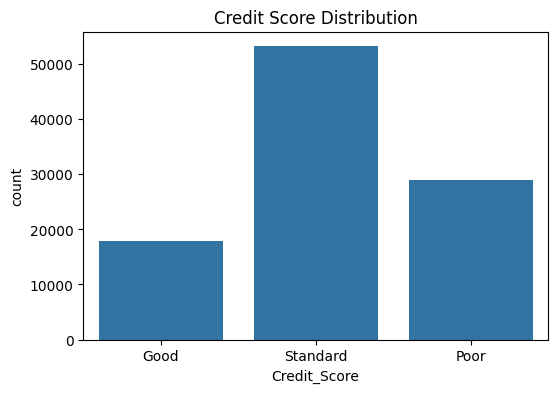

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(6,4))
sns.countplot(data=train, x='Credit_Score')
plt.title('Credit Score Distribution')
plt.show()


#Credit_Score의 분포를 확인한 결과, Standard 등급이 가장 많고 Good 등급이 가장 적었다. 따라서 클래스가 완전히 균등하지 않으며,
#모델 학습 시 Standard 클래스를 더 잘 맞히는 방향으로 편향될 가능성이 있다. 그러므로 단순 정확도뿐 아니라 각 클래스별 예측 성능도 함께 확인할 필요가 있다.


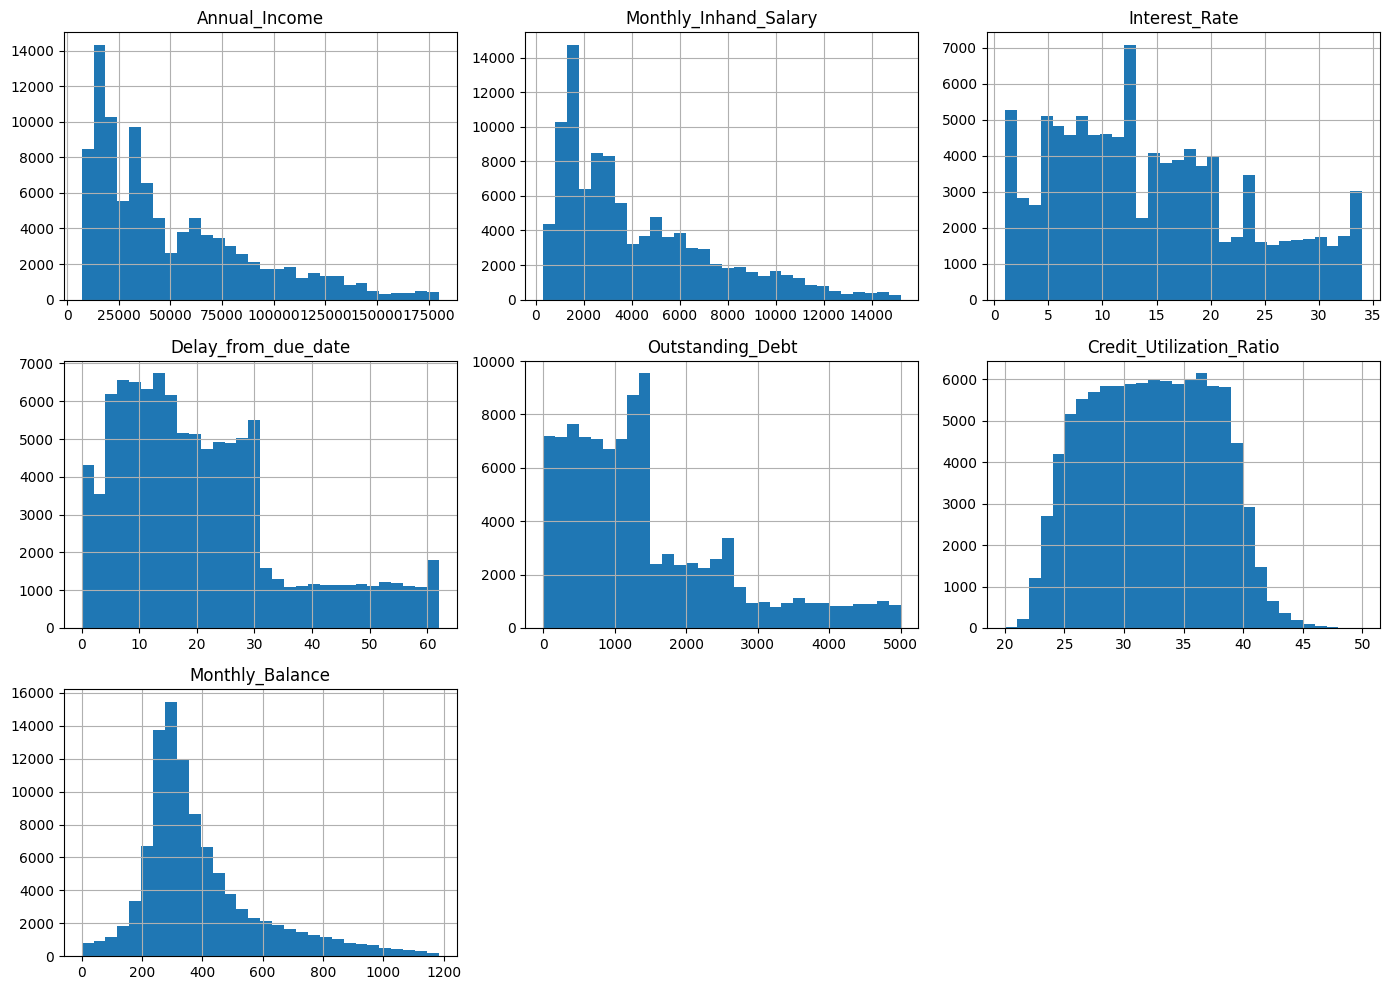

In [16]:
important_numeric = [
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Interest_Rate',
    'Delay_from_due_date',
    'Outstanding_Debt',
    'Credit_Utilization_Ratio',
    'Monthly_Balance'
]

train[important_numeric].hist(figsize=(14, 10), bins=30, grid=True)
plt.tight_layout()
plt.show()


# 주요 수치형 변수들의 분포를 확인한 결과, Annual_Income, Monthly_Inhand_Salary, Delay_from_due_date, Outstanding_Debt는 낮은 값 구간에 데이터가 많이 몰리고 값이 커질수록 빈도가 감소하는 경향을 보였다.
# Monthly_Balance는 200~400 구간에 집중되었으며 일부 큰 값이 존재했고, Credit_Utilization_Ratio는 25~40 구간에 비교적 집중되어 있었다.
# 변수마다 단위와 값의 범위가 다르기 때문에 모델 학습 전 StandardScaler를 이용한 표준화가 필요하다고 판단하였다.



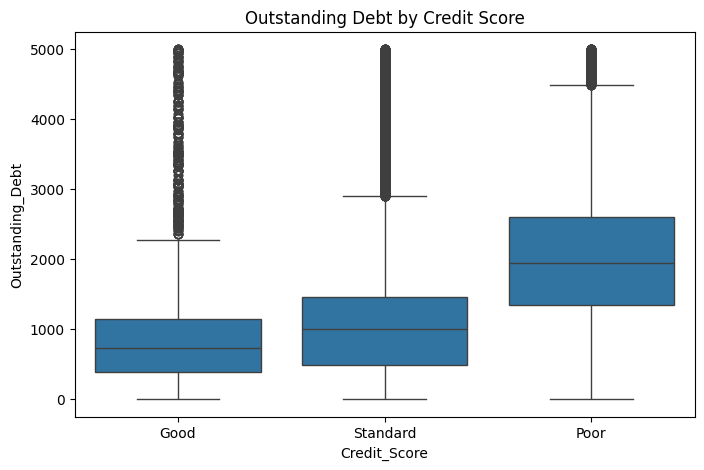

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=train, x='Credit_Score', y='Outstanding_Debt')
plt.title('Outstanding Debt by Credit Score')
plt.show()

#Outstanding_Debt는 고객이 아직 갚지 않은 미상환 부채를 의미한다.
# Outstanding_Debt는 Credit_Score 등급에 따라 뚜렷한 차이를 보였다.
# Good 등급은 부채가 낮고, Poor 등급은 부채가 높게 분포하여 미상환 부채가 신용점수 분류에 중요한 영향을 줄 수 있음을 확인하였다.


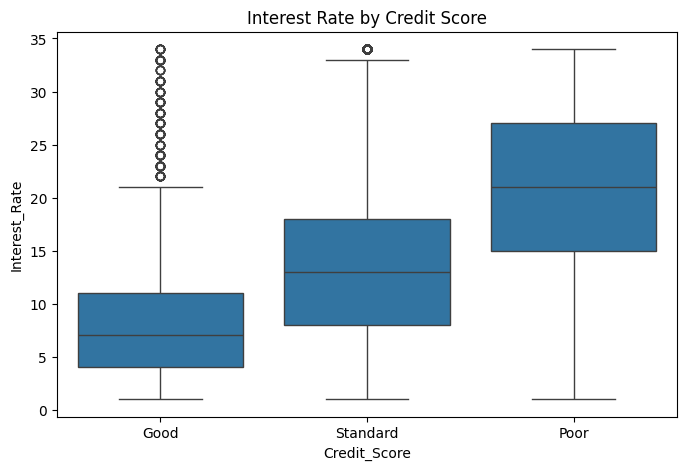

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=train, x='Credit_Score', y='Interest_Rate')
plt.title('Interest Rate by Credit Score')
plt.show()

# Interest_Rate는 고객에게 적용된 신용카드 이자율을 의미한다.
# Interest_Rate는 Credit_Score 등급에 따라 뚜렷한 차이를 보였다.
# Good 등급은 낮은 이자율에, Poor 등급은 높은 이자율에 분포하는 경향이 있다.
# 즉 이자율이 높을수록 신용점수가 낮은 등급(Poor)에 가까워지는 경향이 확인할 수 있다



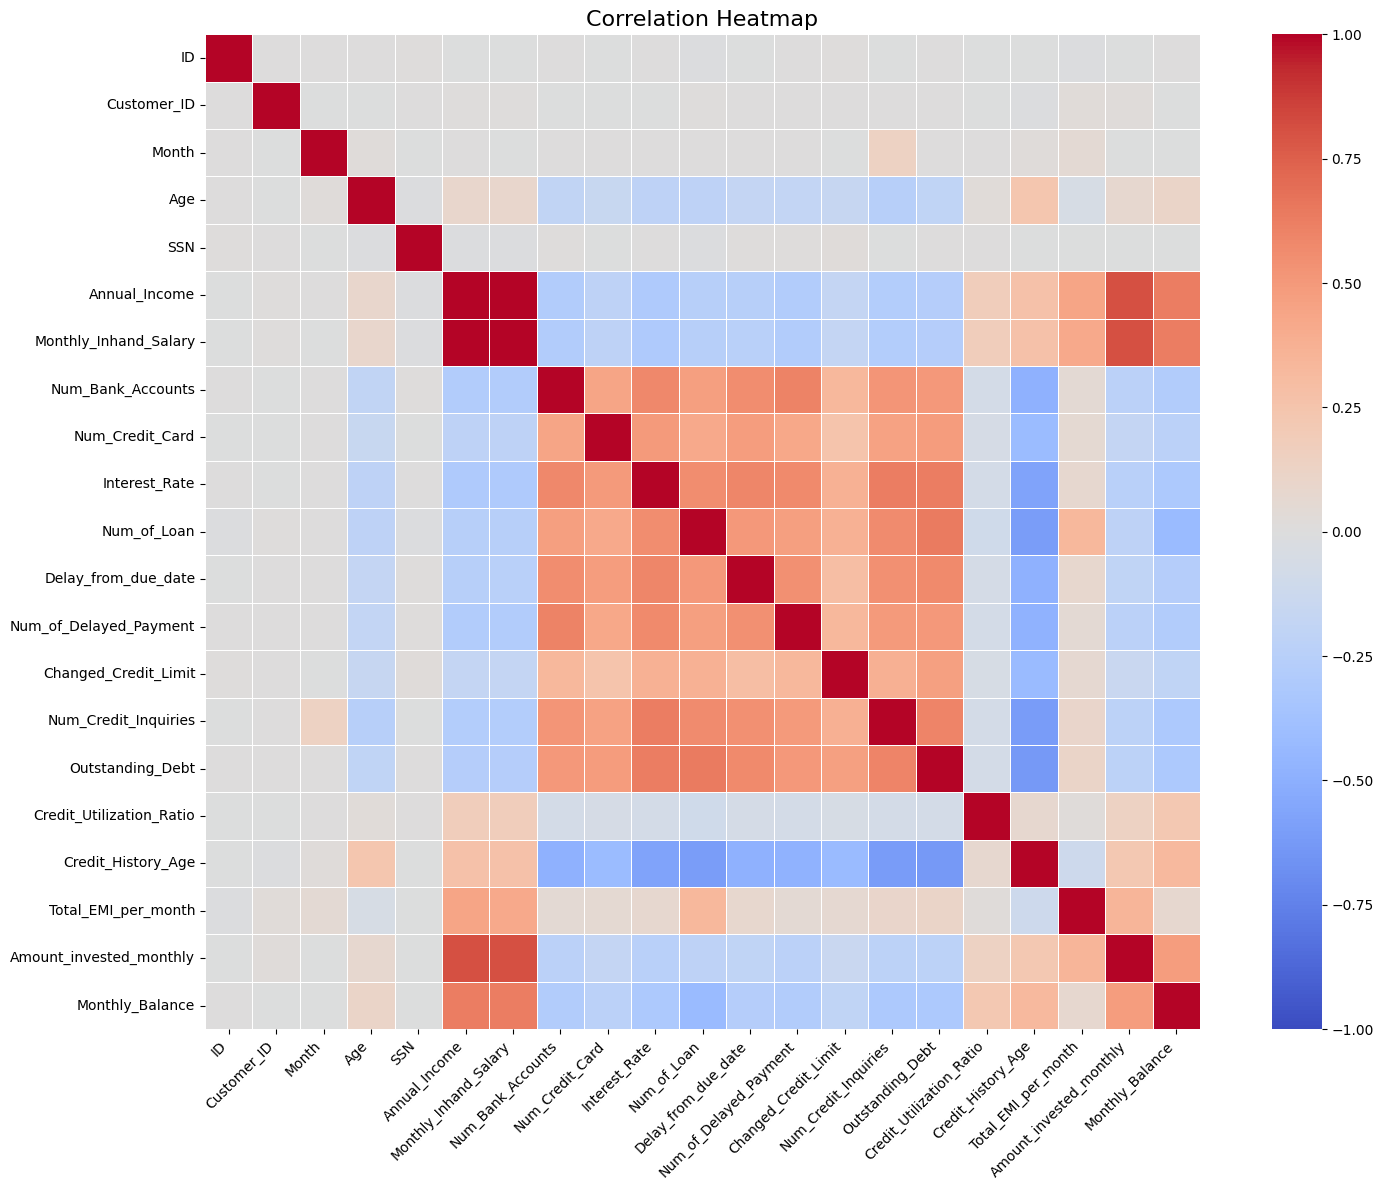

In [19]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    train[numeric_cols].corr(),
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    linecolor='white',
    square=True
)

plt.title('Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



# 상관관계 히트맵을 통해 수치형 변수들 간의 관계를 확인하였다.
# Annual_Income과 Monthly_Inhand_Salary는 강한 양의 상관관계를 보여 소득 관련 정보가 서로 밀접하게 연관되어 있음을 확인하였다.
# Interest_Rate, Num_of_Loan, Delay_from_due_date, Num_of_Delayed_Payment, Outstanding_Debt는 서로 양의 상관관계를 보여
# 대출 규모, 연체 횟수, 미지급 잔액 등이 함께 증가하는 경향을 나타냈다.
# 반면 Credit_History_Age는 이러한 위험 변수들과 음의 상관관계를 보여
# 신용 이력이 길수록 연체 및 미상환 부채 관련 위험이 낮아지는 경향을 확인할 수 있었다.
# 이를 바탕으로 ID, Customer_ID, SSN과 같은 식별자 컬럼은 제거하고,
# 금융 행동 및 신용 상태를 반영하는 변수들을 모델 학습에 활용하였다.

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

file_path = 'train2.csv'
data = pd.read_csv(file_path)



# 전처리 아이디어 및 논리
# 사전 EDA에서 결측치가 없음을 확인했으므로, 본 모델링 코드에서는 별도의 결측치 대체나 삭제를 수행하지 않았다.
# ID, Customer_ID, Name, SSN은 개인 식별자 성격이 강해 일반적인 신용점수 패턴 학습에 부적절하다고 판단하여 제거하였다.
# 범주형 변수는 문자열 형태라 MLP에 직접 입력할 수 없으므로 LabelEncoder로 숫자형으로 변환하였다.
# 단, LabelEncoder는 범주 간 순서가 있는 것처럼 해석될 수 있어 범주형 변수 처리 방식으로는 한계가 있다.
# train/test 분리 후, 데이터 누수를 막기 위해 StandardScaler는 train 데이터에만 fit하고 test 데이터에는 transform만 적용하였다.
# 현재 구현에서는 LabelEncoder로 변환된 범주형 변수와 수치형 변수를 함께 스케일링하였다.

# Feature Selection 및 모델 선택
# Occupation, Type_of_Loan, Credit_Mix, Payment_of_Min_Amount, Payment_Behaviour는 고객의 직업, 대출 유형, 신용 상태, 결제 행동을 반영하므로 입력 변수로 사용하였다.
# Type_of_Loan은 대출 유형 정보를 포함하지만 고유 조합이 많아 단순 LabelEncoding 방식에서는 정보 왜곡이나 과적합 가능성이 있다.
# 본 문제는 Good, Standard, Poor 세 클래스를 예측하는 다중분류 문제이므로 출력 노드를 3개로 설정하고 CrossEntropyLoss를 사용하는 MLP 모델을 선택하였다.


data = data.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])

categorical_columns = ['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

target_encoder = LabelEncoder()
data['Credit_Score'] = target_encoder.fit_transform(data['Credit_Score'])

X = data.drop('Credit_Score', axis=1).values
y = data['Credit_Score'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


class CreditScoreDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = CreditScoreDataset(X_train, y_train)
test_dataset = CreditScoreDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


input_size = X_train.shape[1]
model = MLP(input_size).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    model.eval()
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total_val += targets.size(0)
            correct_val += (predicted == targets).sum().item()

    train_accuracy = 100 * correct_train / total_train
    val_accuracy = 100 * correct_val / total_val
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
          f'학습 정확도: {train_accuracy:.2f}%, 평가 정확도: {val_accuracy:.2f}%')


print(f'Final Validation Accuracy: {val_accuracy:.2f}%')





Epoch [1/20], Loss: 0.6893, 학습 정확도: 68.41%, 평가 정확도: 69.80%
Epoch [2/20], Loss: 0.6533, 학습 정확도: 70.21%, 평가 정확도: 70.30%
Epoch [3/20], Loss: 0.6433, 학습 정확도: 70.60%, 평가 정확도: 70.48%
Epoch [4/20], Loss: 0.6368, 학습 정확도: 70.80%, 평가 정확도: 70.51%
Epoch [5/20], Loss: 0.6318, 학습 정확도: 71.17%, 평가 정확도: 70.80%
Epoch [6/20], Loss: 0.6282, 학습 정확도: 71.24%, 평가 정확도: 70.81%
Epoch [7/20], Loss: 0.6246, 학습 정확도: 71.47%, 평가 정확도: 70.97%
Epoch [8/20], Loss: 0.6217, 학습 정확도: 71.44%, 평가 정확도: 70.83%
Epoch [9/20], Loss: 0.6189, 학습 정확도: 71.68%, 평가 정확도: 70.87%
Epoch [10/20], Loss: 0.6160, 학습 정확도: 71.82%, 평가 정확도: 71.17%
Epoch [11/20], Loss: 0.6137, 학습 정확도: 71.93%, 평가 정확도: 71.19%
Epoch [12/20], Loss: 0.6111, 학습 정확도: 72.05%, 평가 정확도: 71.22%
Epoch [13/20], Loss: 0.6089, 학습 정확도: 72.07%, 평가 정확도: 71.39%
Epoch [14/20], Loss: 0.6067, 학습 정확도: 72.28%, 평가 정확도: 71.22%
Epoch [15/20], Loss: 0.6048, 학습 정확도: 72.41%, 평가 정확도: 71.45%
Epoch [16/20], Loss: 0.6030, 학습 정확도: 72.48%, 평가 정확도: 71.47%
Epoch [17/20], Loss: 0.6014, 학습 정확도: 72.44%, 평가 정

# TabTransFormer

In [21]:
!pip install tab-transformer-pytorch


In [29]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from tab_transformer_pytorch import TabTransformer

# Feature Selection 및 모델 선택, 튜닝 기준
# ID, Customer_ID, Name, SSN은 개인 식별자 성격이 강해 제거하였다.
# Occupation, Credit_Mix, Payment_of_Min_Amount, Payment_Behaviour는 신용 상태와 결제 행동을 반영하는 범주형 변수로 사용하였다.
# Type_of_Loan은 고유 문자열 조합이 많아 원본은 제거하고, 대출 개수와 주요 대출 유형 여부 파생변수로 변환하였다.
# 수치형 변수는 소득, 부채, 연체, 신용 이력 관련 변수와 파생변수를 함께 사용하였다.
# 범주형 변수와 수치형 변수를 분리 처리하기 위해 TabTransformer를 선택하였고, lr, dropout, weight_decay, early stopping으로 튜닝하였다.


# 실험 결과가 매번 크게 달라지지 않도록 seed를 고정한다.
SEED = 42
DATA_PATH = "train2.csv"
BATCH_SIZE = 256
EPOCHS = 60
PATIENCE = 7
LR = 0.001
WEIGHT_DECAY = 0.0001


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def safe_divide(a, b):
    b = pd.Series(b).replace(0, np.nan)
    result = a / (b + 0.000001)
    return result.replace([np.inf, -np.inf], np.nan).fillna(0)


def add_derived_features(df):
    df = df.copy()

    salary = df["Monthly_Inhand_Salary"]
    annual_income = df["Annual_Income"]
    age = df["Age"]
    debt = df["Outstanding_Debt"]
    credit_history = df["Credit_History_Age"]
    num_accounts = df["Num_Bank_Accounts"]
    num_cards = df["Num_Credit_Card"]
    num_loans = df["Num_of_Loan"]
    delayed = df["Num_of_Delayed_Payment"]
    delay_days = df["Delay_from_due_date"]
    inquiries = df["Num_Credit_Inquiries"]
    emi = df["Total_EMI_per_month"]
    invested = df["Amount_invested_monthly"]
    balance = df["Monthly_Balance"]
    interest = df["Interest_Rate"]

    # 파생변수는 각 행 내부의 값만 사용해 계산한다.
    # 전체 평균 같은 통계를 쓰는 게 아니라 행 내부 값끼리 계산해서 만든 변수들이다.
    df["Income_per_Age"] = safe_divide(annual_income, age)
    df["Monthly_Salary_per_Age"] = safe_divide(salary, age)
    df["Debt_to_Annual_Income"] = safe_divide(debt, annual_income)
    df["Debt_to_Monthly_Salary"] = safe_divide(debt, salary)
    df["EMI_to_Monthly_Salary"] = safe_divide(emi, salary)
    df["Invest_to_Monthly_Salary"] = safe_divide(invested, salary)
    df["Balance_to_Monthly_Salary"] = safe_divide(balance, salary)
    df["Total_Outflow"] = emi + invested
    df["Outflow_to_Monthly_Salary"] = safe_divide(df["Total_Outflow"], salary)
    df["Disposable_Ratio"] = safe_divide(balance, salary - emi)

    df["Loan_per_Account"] = safe_divide(num_loans, num_accounts + 1)
    df["Card_per_Account"] = safe_divide(num_cards, num_accounts + 1)
    df["Delayed_Payment_Ratio"] = safe_divide(delayed, num_loans + 1)
    df["Delay_per_Delayed_Payment"] = safe_divide(delay_days, delayed + 1)
    df["Inquiry_per_Card"] = safe_divide(inquiries, num_cards + 1)
    df["Interest_per_Loan"] = safe_divide(interest, num_loans + 1)
    df["Debt_Interest_Burden"] = debt * interest / 100
    df["Debt_per_Credit_History"] = safe_divide(debt, credit_history + 1)
    df["Credit_History_Years"] = credit_history / 12
    df["Credit_History_per_Age"] = safe_divide(credit_history, age * 12)
    df["Utilization_Debt_Interaction"] = df["Credit_Utilization_Ratio"] * debt
    df["Limit_Delay_Interaction"] = df["Changed_Credit_Limit"] * delay_days

    df["High_Delay_Flag"] = (delay_days >= 30).astype(int)
    df["Many_Delayed_Payment_Flag"] = (delayed >= 15).astype(int)
    df["High_Debt_Flag"] = (debt >= 2000).astype(int)
    df["High_Interest_Flag"] = (interest >= 20).astype(int)
    df["Thin_History_Flag"] = (credit_history < 120).astype(int)

    df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

    behaviour = df["Payment_Behaviour"].astype(str)
    df["Spend_Level"] = behaviour.str.extract(r"^(High|Low)_spent", expand=False).fillna("Unknown")
    df["Payment_Value_Level"] = behaviour.str.extract(
        r"_(Small|Medium|Large)_value_payments$", expand=False
    ).fillna("Unknown")

    loan_text = df["Type_of_Loan"].fillna("Not Specified").astype(str)
    no_loan_values = ["Not Specified", "nan", "None", ""]

    df["Loan_Type_Count"] = loan_text.apply(
        lambda x: 0 if x.strip() in no_loan_values else len(x.split(","))
    )
    df["Has_Credit_Builder_Loan"] = loan_text.str.contains("Credit-Builder", case=False, na=False).astype(int)
    df["Has_Personal_Loan"] = loan_text.str.contains("Personal", case=False, na=False).astype(int)
    df["Has_Mortgage_Loan"] = loan_text.str.contains("Mortgage", case=False, na=False).astype(int)
    df["Has_Auto_Loan"] = loan_text.str.contains("Auto", case=False, na=False).astype(int)
    df["Has_Student_Loan"] = loan_text.str.contains("Student", case=False, na=False).astype(int)
    df["Has_Home_Equity_Loan"] = loan_text.str.contains("Home Equity", case=False, na=False).astype(int)
    df["Has_Debt_Consolidation_Loan"] = loan_text.str.contains("Debt Consolidation", case=False, na=False).astype(int)
    df["Has_Payday_Loan"] = loan_text.str.contains("Payday", case=False, na=False).astype(int)

    # 비율 계산 중 생긴 이상값은 학습에 넣기 어렵기 때문에 0으로 정리한다.
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
    df[numeric_cols] = df[numeric_cols].fillna(0)

    return df


class CreditTabDataset(Dataset):
    def __init__(self, x_cat, x_cont, y):
        self.x_cat = torch.tensor(x_cat, dtype=torch.long)
        self.x_cont = torch.tensor(x_cont, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x_cat[idx], self.x_cont[idx], self.y[idx]


def encode_categorical(train_df, valid_df, cat_cols):
    train_cat = []
    valid_cat = []
    categories = []

    for col in cat_cols:
        values = train_df[col].astype(str).fillna("Unknown")
        known_values = sorted(values.unique())
        mapping = {value: idx + 1 for idx, value in enumerate(known_values)}

        train_encoded = values.map(mapping).fillna(0).astype(int).to_numpy()
        valid_encoded = (
            valid_df[col].astype(str)
            .fillna("Unknown")
            .map(mapping)
            .fillna(0)
            .astype(int)
            .to_numpy()
        )

        train_cat.append(train_encoded)
        valid_cat.append(valid_encoded)
        categories.append(len(mapping) + 1)

    return np.stack(train_cat, axis=1), np.stack(valid_cat, axis=1), tuple(categories)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_cat, x_cont, y in loader:
            x_cat = x_cat.to(device)
            x_cont = x_cont.to(device)
            y = y.to(device)

            logits = model(x_cat, x_cont)
            loss = criterion(logits, y)
            total_loss += loss.item()

            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    accuracy = accuracy_score(all_targets, all_preds)
    return total_loss / len(loader), accuracy, np.array(all_targets), np.array(all_preds)


seed_everything(SEED)

data = pd.read_csv(DATA_PATH)
data = data.drop(columns=["ID", "Customer_ID", "Name", "SSN"])
data = add_derived_features(data)

# Type_of_Loan은 값 조합이 너무 많아서 그대로 넣으면 과적합될 수 있다.
# 그래서 원본 문자열은 빼고, 대출 개수/대출 종류 여부만 파생변수로 사용한다.
print("Type_of_Loan unique 개수:", data["Type_of_Loan"].nunique())
data = data.drop(columns=["Type_of_Loan"])

target_encoder = LabelEncoder()
data["Credit_Score"] = target_encoder.fit_transform(data["Credit_Score"])

cat_cols = [
    "Occupation",
    "Credit_Mix",
    "Payment_of_Min_Amount",
    "Payment_Behaviour",
    "Spend_Level",
    "Payment_Value_Level",
]

num_cols = [col for col in data.columns if col not in cat_cols + ["Credit_Score"]]

train_df, valid_df = train_test_split(
    data,
    test_size=0.2,
    random_state=SEED,
    stratify=data["Credit_Score"],
)

x_train_cat, x_valid_cat, categories = encode_categorical(train_df, valid_df, cat_cols)

scaler = StandardScaler()
x_train_cont = scaler.fit_transform(train_df[num_cols])
x_valid_cont = scaler.transform(valid_df[num_cols])

y_train = train_df["Credit_Score"].to_numpy()
y_valid = valid_df["Credit_Score"].to_numpy()

train_dataset = CreditTabDataset(x_train_cat, x_train_cont, y_train)
valid_dataset = CreditTabDataset(x_valid_cat, x_valid_cont, y_valid)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TabTransformer(
    categories=categories,
    num_continuous=len(num_cols),
    dim=32,
    dim_out=3,
    depth=4,
    heads=4,
    attn_dropout=0.2,
    ff_dropout=0.2,
    mlp_hidden_mults=(2, 1),
    mlp_act=nn.ReLU()
).to(device)

# train 데이터 기준으로 클래스별 개수를 계산해 class weight를 만든다.
# 표본 수가 적은 클래스의 loss 비중을 높여 소수 클래스가 덜 무시되도록 한다.
class_counts = np.bincount(y_train)
class_weights = len(y_train) / (len(class_counts) * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
)

best_valid_acc = 0
best_epoch = 0
best_state = None
patience_count = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0
    train_preds = []
    train_targets = []

    for x_cat, x_cont, y in train_loader:
        x_cat = x_cat.to(device)
        x_cont = x_cont.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x_cat, x_cont)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
        train_targets.extend(y.detach().cpu().numpy())

    train_acc = accuracy_score(train_targets, train_preds)

    valid_loss, valid_acc, valid_targets, valid_preds = evaluate(
        model,
        valid_loader,
        criterion,
        device,
    )

    scheduler.step(valid_acc)

    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] "
        f"Train Loss: {train_loss / len(train_loader):.4f}, "
        f"Train Acc: {train_acc * 100:.2f}%, "
        f"Valid Loss: {valid_loss:.4f}, "
        f"Valid Acc: {valid_acc * 100:.2f}%, "
        f"Best: {best_valid_acc * 100:.2f}%"
    )

    if patience_count >= PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

if best_state is not None:
    model.load_state_dict(best_state)

valid_loss, valid_acc, valid_targets, valid_preds = evaluate(
    model,
    valid_loader,
    criterion,
    device,
)

print("\n===== TabTransformer 최종 결과 =====")
print(f"최고 Validation Accuracy: {best_valid_acc * 100:.2f}%")
print(f"최고 성능 Epoch: {best_epoch}")
print(f"최고 모델 기준 최종 평가 Accuracy: {valid_acc * 100:.2f}%")
print("\nClassification Report")
print(classification_report(valid_targets, valid_preds, target_names=target_encoder.classes_))


# 기존 MLP는 범주형 변수를 LabelEncoder로 숫자화한 뒤 수치형 변수와 함께 스케일링하여 입력하였다.
# 이 방식은 구현이 간단하지만, 범주형 변수에 실제로는 없는 순서 관계가 생길 수 있고 복잡한 범주 정보를 충분히 반영하기 어렵다.
# 개선 모델에서는 범주형 변수와 수치형 변수를 분리 처리하는 TabTransformer를 사용하였다.
# 또한 부채 대비 소득, 월급 대비 상환 부담, 연체 비율, 신용 거래 기간 관련 파생변수를 추가하였다.
# Type_of_Loan은 고유 문자열 조합이 많아 원본 대신 대출 개수와 주요 대출 유형 여부 변수로 변환하였다.
# Good 클래스의 표본 수가 상대적으로 적어 class weight를 적용하였고,
# validation 성능이 더 이상 개선되지 않을 때 early stopping으로 학습을 멈추도록 하였다.



Type_of_Loan unique 개수: 6261
Target classes: ['Good' 'Poor' 'Standard']
Class counts: [14262 23199 42539]
Class weights: tensor([1.8698, 1.1495, 0.6269], device='cuda:0')
Epoch [01/60] Train Loss: 0.7347, Train Acc: 65.16%, Valid Loss: 0.7036, Valid Acc: 66.25%, Best: 66.25%
Epoch [02/60] Train Loss: 0.6769, Train Acc: 67.22%, Valid Loss: 0.6664, Valid Acc: 67.51%, Best: 67.51%
Epoch [03/60] Train Loss: 0.6559, Train Acc: 67.75%, Valid Loss: 0.6583, Valid Acc: 69.05%, Best: 69.05%
Epoch [04/60] Train Loss: 0.6428, Train Acc: 68.01%, Valid Loss: 0.6472, Valid Acc: 67.17%, Best: 69.05%
Epoch [05/60] Train Loss: 0.6304, Train Acc: 68.41%, Valid Loss: 0.6349, Valid Acc: 68.92%, Best: 69.05%
Epoch [06/60] Train Loss: 0.6170, Train Acc: 68.91%, Valid Loss: 0.6337, Valid Acc: 67.38%, Best: 69.05%
Epoch [07/60] Train Loss: 0.6014, Train Acc: 69.41%, Valid Loss: 0.6190, Valid Acc: 68.55%, Best: 69.05%
Epoch [08/60] Train Loss: 0.5715, Train Acc: 70.54%, Valid Loss: 0.6029, Valid Acc: 70.29%, Be